In [5]:
# ═══════════════════════════════════════════════════════════
# Cell 1 — Setup
# ═══════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

LIB_PATH = r"C:\Miscellaneous\Coding_Projects\Python\mri_processing\processing\madi_gpu\Custom_MADI\data\libraries\madi_dense_intermediate_high_partial.npz"

# Nominal production grid (from madi/config.py)
RHO_MIN, RHO_MAX, N_RHO = 1e4, 1e7, 64      # cells/uL
V_MIN,   V_MAX,   N_V   = 0.01, 200.0, 64   # pL
VI_LO, VI_HI = 0.40, 0.99

GAMMA = 2.675e8      # rad/s/T
D0 = 3.0e-3          # mm^2/s  (3.0 um^2/ms)
TRUST_FLOOR = 0.015
N_B = 25

# log-spacing of one grid node (natural log, matches our derivative steps)
H_LOG_RHO = np.log(RHO_MAX / RHO_MIN) / (N_RHO - 1)
H_LOG_V   = np.log(V_MAX / V_MIN)   / (N_V - 1)

print(f"one rho node = {H_LOG_RHO:.6f} nat  ({np.exp(H_LOG_RHO):.6f}x)")
print(f"one V   node = {H_LOG_V:.6f} nat  ({np.exp(H_LOG_V):.6f}x)")

one rho node = 0.109647 nat  (1.115884x)
one V   node = 0.157198 nat  (1.170228x)


In [7]:
# ═══════════════════════════════════════════════════════════
# Cell 2 — Load and inventory
#
# vectors is ~12342 x 31125. As float32 that is ~1.5 GB, so we
# load once and keep it. Everything downstream slices columns.
# ═══════════════════════════════════════════════════════════
raw = np.load(LIB_PATH, allow_pickle=True)
print("arrays present:", sorted(raw.files))

vectors = np.asarray(raw["vectors"], dtype=np.float64)
rhos    = np.asarray(raw["rhos"],  dtype=np.float64)
Vs      = np.asarray(raw["Vs"],    dtype=np.float64)
kios    = np.asarray(raw["kios"],  dtype=np.float64)

# v5 diagnostic arrays — optional
HAS_VAR    = "signal_variance" in raw.files
HAS_SUBSET = "ensemble_means_subset" in raw.files
HAS_IMAG   = "signal_imag" in raw.files
signal_variance = np.asarray(raw["signal_variance"], np.float64) if HAS_VAR else None

# column metadata
def _get(name, fallback=None):
    return np.asarray(raw[name]) if name in raw.files else fallback

pair_deltas = _get("pair_deltas")
pair_Deltas = _get("pair_Deltas")
b_values    = _get("b_values", np.arange(0, 12001, 500, dtype=float))
n_entries, n_columns = vectors.shape
n_pairs = n_columns // N_B

if pair_deltas is None or pair_Deltas is None:
    raise RuntimeError("pair_deltas / pair_Deltas missing — cannot map columns to (delta,Delta).")

print(f"\n{n_entries} entries x {n_columns} columns = {n_pairs} pairs x {N_B} b")
print(f"rho: {rhos.min():.4g} .. {rhos.max():.4g} cells/uL")
print(f"V:   {Vs.min():.4g} .. {Vs.max():.4g} pL")
print(f"kio: {kios.min():g} .. {kios.max():g} s^-1 ({len(np.unique(kios))} unique)")
print(f"v_i: {(rhos*Vs*1e-6).min():.4f} .. {(rhos*Vs*1e-6).max():.4f}")

print("\nv5 diagnostic arrays:")
print(f"  signal_variance       : {'PRESENT' if HAS_VAR else 'ABSENT'}")
print(f"  ensemble_means_subset : {'PRESENT' if HAS_SUBSET else 'ABSENT'}")
print(f"  signal_imag           : {'PRESENT' if HAS_IMAG else 'ABSENT'}")
if not HAS_VAR:
    print("\n  !! Without signal_variance the Fisher bias correction cannot run.")
    print("     E[J_hat^2] = J^2 + Var(J_hat), so the FIM will be inflated and the")
    print("     CRLB deflated by an unknown amount. Treat all results as OPTIMISTIC.")


weights = _get("weights")
print("weights: ", weights.shape)
print("weights: ", weights)


arrays present: ['Vs', 'b_values', 'build_metadata_json', 'ensemble_means_subset', 'ensemble_subset_b_values', 'ensemble_subset_n_b', 'ensemble_subset_pair_Deltas', 'ensemble_subset_pair_deltas', 'entry_metadata_json', 'h_ms', 'has_weights', 'is_free_water', 'kio_analytic_eq5', 'kios', 'library_schema', 'n_b', 'nominal_Vs', 'nominal_kios', 'nominal_rhos', 'pair_Deltas', 'pair_deltas', 'pps', 'rhos', 'signal_imag', 'signal_variance', 'vectors', 'vis', 'weights']

12342 entries x 31125 columns = 1245 pairs x 25 b
rho: 1.113e+05 .. 1e+07 cells/uL
V:   0.04116 .. 8.642 pL
kio: 0 .. 130 s^-1 (51 unique)
v_i: 0.4010 .. 0.9867

v5 diagnostic arrays:
  signal_variance       : PRESENT
  ensemble_means_subset : PRESENT
  signal_imag           : PRESENT
weights:  (12342,)
weights:  [ 3778.37550792  7556.75101583  7556.75101583 ... 38919.60794102
 38919.60794102 19459.80397051]


In [8]:
# ═══════════════════════════════════════════════════════════
# Cell 3 — Recover nominal grid indices from realized labels
#
# Realized rho/V deviate from nominal by <1% (Poisson count and
# v_i realization tolerance), while node spacing is 11.6% / 17.0%,
# so rounding to the nearest index is unambiguous. We index on
# nominal, but every derivative DENOMINATOR uses realized labels.
# ═══════════════════════════════════════════════════════════
def rho_index(rho):  return np.rint((N_RHO-1)*np.log(rho/RHO_MIN)/np.log(RHO_MAX/RHO_MIN)).astype(int)
def v_index(V):      return np.rint((N_V-1)  *np.log(V/V_MIN)   /np.log(V_MAX/V_MIN)  ).astype(int)

i_rho = rho_index(rhos)
j_V   = v_index(Vs)
kio_grid = np.unique(kios)
k_idx = np.searchsorted(kio_grid, kios)

# residual check: how far are realized labels from their nominal node?
rho_nom = RHO_MIN*np.exp(i_rho*H_LOG_RHO)
V_nom   = V_MIN  *np.exp(j_V  *H_LOG_V)
print(f"max |log(rho_real/rho_nom)| = {np.abs(np.log(rhos/rho_nom)).max():.4f} nat "
      f"(node = {H_LOG_RHO:.4f})")
print(f"max |log(V_real/V_nom)|     = {np.abs(np.log(Vs/V_nom)).max():.4f} nat "
      f"(node = {H_LOG_V:.4f})")
assert np.abs(np.log(rhos/rho_nom)).max() < H_LOG_RHO/2, "rho index recovery ambiguous"
assert np.abs(np.log(Vs/V_nom)).max()     < H_LOG_V/2,   "V index recovery ambiguous"

# sparse lookup: (i,j,k) -> entry row
lookup = {}
for e in range(n_entries):
    lookup[(i_rho[e], j_V[e], k_idx[e])] = e

print(f"\nrho indices present: {i_rho.min()} .. {i_rho.max()} ({len(np.unique(i_rho))} columns)")
print(f"V   indices present: {j_V.min()} .. {j_V.max()}")
print(f"(rho,V) pairs: {len(set(zip(i_rho, j_V)))}")

# stencil availability per axis, k=1
def has_stencil(i, j, k, axis):
    d = {"rho": (1,0,0), "V": (0,1,0), "kio": (0,0,1)}[axis]
    return ((i-d[0], j-d[1], k-d[2]) in lookup) and ((i+d[0], j+d[1], k+d[2]) in lookup)

for axis in ("rho", "V", "kio"):
    n_ok = sum(has_stencil(i_rho[e], j_V[e], k_idx[e], axis) for e in range(n_entries))
    print(f"  entries with a k=1 central stencil in {axis:4s}: {n_ok:6d} / {n_entries}")

max |log(rho_real/rho_nom)| = 0.0024 nat (node = 0.1096)
max |log(V_real/V_nom)|     = 0.0029 nat (node = 0.1572)

rho indices present: 22 .. 63 (42 columns)
V   indices present: 9 .. 43
(rho,V) pairs: 242
  entries with a k=1 central stencil in rho :   8874 / 12342
  entries with a k=1 central stencil in V   :   8058 / 12342
  entries with a k=1 central stencil in kio :  11858 / 12342


In [9]:
# ═══════════════════════════════════════════════════════════
# Cell 4 — Column metadata, protocols, feasibility masks
#
# Column layout is pair-major, b-minor: c = pair_idx*25 + b_idx.
# Three exclusions before a column may contribute to the FIM:
#   1. b = 0 (S is exactly 1, derivative is exactly 0)
#   2. trust floor: simulated S/S0 < 0.015 is Monte Carlo noise
#   3. gradient feasibility: G <= G_max on real hardware
# ═══════════════════════════════════════════════════════════
col_pair = np.repeat(np.arange(n_pairs), N_B)
col_b    = np.tile(b_values, n_pairs)
col_del  = pair_deltas[col_pair].astype(float)
col_Del  = pair_Deltas[col_pair].astype(float)

def gradient_T_per_m(b_smm2, delta_ms, Delta_ms):
    """b = (gamma*G*delta)^2 * (Delta - delta/3)  ->  G in T/m."""
    d, D = delta_ms*1e-3, Delta_ms*1e-3
    tD = D - d/3.0
    with np.errstate(divide="ignore", invalid="ignore"):
        G = np.sqrt(b_smm2*1e6 / ((GAMMA*d)**2 * tD))
    return np.where(tD > 0, G, np.inf)

col_G = gradient_T_per_m(col_b, col_del, col_Del)

def select_columns(pairs, b_lo=500., b_hi=5000., G_max=0.080):
    """pairs: list of (delta_ms, Delta_ms). Returns column indices."""
    want = set((int(d), int(D)) for d, D in pairs)
    m = np.array([(int(d), int(D)) in want for d, D in zip(col_del, col_Del)])
    m &= (col_b >= b_lo) & (col_b <= b_hi)      # excludes b=0 automatically
    m &= (col_G <= G_max)
    return np.flatnonzero(m)

PROTOCOLS = {
    "MADI-II-like  (20,50)":  [(20, 50)],
    "MADI-III-like (7,25)":   [(7, 25)],
    "multi-D  (20,25/50/80)": [(20, 25), (20, 50), (20, 80)],
    "multi-d  (7/15/30, 50)": [(7, 50), (15, 50), (30, 50)],
}

print(f"{'protocol':26s} {'cols':>6s} {'G_max used':>12s}")
for name, pairs in PROTOCOLS.items():
    c = select_columns(pairs)
    gmax = col_G[c].max()*1e3 if len(c) else np.nan
    print(f"{name:26s} {len(c):6d} {gmax:9.1f} mT/m")

protocol                     cols   G_max used
MADI-II-like  (20,50)          10      63.5 mT/m
MADI-III-like (7,25)            1      79.3 mT/m
multi-D  (20,25/50/80)         26      75.6 mT/m
multi-d  (7/15/30, 50)         21      78.8 mT/m


In [10]:
# ═══════════════════════════════════════════════════════════
# Cell 5 — ANALYTIC GATE (run this before trusting anything)
#
# There is no free-water atom in this partial library, so we
# validate the FIM machinery against closed-form curves instead.
#
# For S(b) = exp(-b*D):   dS/dD = -b*S
#   F_DD = sum_c (b_c S_c)^2 / sigma^2      CRLB = 1/sqrt(F_DD)
#
# We feed synthetic entries through the SAME finite-difference
# and FIM code used on the library. If this does not reproduce
# the closed form, nothing downstream means anything.
# ═══════════════════════════════════════════════════════════
def fim_from_jacobian(J, sigma):
    """J: (n_cols, n_params). Returns F = J^T Sigma^-1 J."""
    W = J / sigma[:, None]
    return W.T @ W

# synthetic 1-parameter test
b_test = np.arange(500., 5001., 500.)
D_nodes = np.array([0.95, 1.00, 1.05]) * D0          # +/-5% stencil
S_nodes = np.exp(-b_test[None, :] * D_nodes[:, None])
sigma = np.full(b_test.size, 0.02)

J_fd = ((S_nodes[2] - S_nodes[0]) / (D_nodes[2] - D_nodes[0]))[:, None]
F_fd = fim_from_jacobian(J_fd, sigma)
crlb_fd = np.sqrt(np.linalg.inv(F_fd)[0, 0])

S_ex = np.exp(-b_test * D0)
J_ex = (-b_test * S_ex)[:, None]
F_ex = fim_from_jacobian(J_ex, sigma)
crlb_ex = np.sqrt(np.linalg.inv(F_ex)[0, 0])

rel = abs(crlb_fd - crlb_ex) / crlb_ex
print(f"analytic CRLB(D0)        = {crlb_ex:.6e} mm^2/s")
print(f"finite-difference CRLB   = {crlb_fd:.6e} mm^2/s")
print(f"relative difference      = {rel:.3e}")
print(f"\nGATE: {'PASS' if rel < 5e-3 else 'FAIL — stop and debug'}")
print("(residual is second-order truncation from the +/-5% stencil, not a code error)")

analytic CRLB(D0)        = 1.620625e-04 mm^2/s
finite-difference CRLB   = 1.618100e-04 mm^2/s
relative difference      = 1.558e-03

GATE: PASS
(residual is second-order truncation from the +/-5% stencil, not a code error)


In [11]:
# ═══════════════════════════════════════════════════════════
# Cell 6 — Derivatives, FIM, CRLB, degeneracy
#
# theta = (log rho, log V, k_io).
#
# Log parameters for two reasons: the grid is log-spaced so the
# step is constant, and the CRLB on a log parameter IS the
# fractional precision (sigma_logV = 0.20 means 20% CV on V).
#
# Central differences, and the four entries used for the rho and
# V derivatives are DISJOINT, so their MC noises are independent
# and the FIM off-diagonals (which carry the degeneracy) stay
# unbiased even before correction.
# ═══════════════════════════════════════════════════════════
@dataclass
class NodeResult:
    i: int; j: int; k: int
    rho: float; V: float; kio: float; vi: float
    F: np.ndarray; C: np.ndarray
    crlb: np.ndarray            # [sigma_logrho, sigma_logV, sigma_kio]
    kappa: np.ndarray           # degeneracy inflation per parameter
    sloppy_vec: np.ndarray      # 2D unit vector in (log rho, log V)
    sloppy_angle_deg: float     # angle to the constant-v_i direction
    cond: float
    beta_max: float             # worst Var(J)/J^2 over columns, or nan

AXES = {"rho": (1,0,0), "V": (0,1,0), "kio": (0,0,1)}

def node_fisher(i, j, k, cols, sigma_m, kstencil=1, correct_bias=True):
    """Debiased FIM at one grid node. Returns None if any stencil is missing."""
    e0 = lookup.get((i, j, k))
    if e0 is None:
        return None

    J = np.empty((len(cols), 3))
    varJ = np.zeros((len(cols), 3))

    for p, (axis, d) in enumerate(AXES.items()):
        lo = lookup.get((i-kstencil*d[0], j-kstencil*d[1], k-kstencil*d[2]))
        hi = lookup.get((i+kstencil*d[0], j+kstencil*d[1], k+kstencil*d[2]))
        if lo is None or hi is None:
            return None

        # step from REALIZED labels, never nominal nodes
        if axis == "rho":   h = np.log(rhos[hi]) - np.log(rhos[lo])
        elif axis == "V":   h = np.log(Vs[hi])   - np.log(Vs[lo])
        else:               h = kios[hi] - kios[lo]

        J[:, p] = (vectors[hi, cols] - vectors[lo, cols]) / h

        if HAS_VAR:
            # Cov(S+,S-) is unavailable without ensemble_means_subset.
            # Setting it to zero UPPER-bounds Var(J), so the correction
            # over-subtracts. That errs toward a pessimistic CRLB, which
            # is the safe direction.
            varJ[:, p] = (signal_variance[hi, cols] + signal_variance[lo, cols]) / (h*h * 40.0)

    F = fim_from_jacobian(J, sigma_m)
    if correct_bias and HAS_VAR:
        F -= np.diag((varJ / sigma_m[:, None]**2).sum(axis=0))

    # guard: over-correction can push F non-PSD in noise-dominated corners
    if np.any(np.linalg.eigvalsh(F) <= 0):
        return None

    C = np.linalg.inv(F)
    crlb = np.sqrt(np.diag(C))
    kappa = np.sqrt(np.diag(C) * np.diag(F))          # >= 1 always

    # sloppy direction in (log rho, log V), marginalized over k_io
    C2 = C[:2, :2]
    w, Vec = np.linalg.eigh(C2)
    sloppy = Vec[:, np.argmax(w)]
    hyper = np.array([1.0, -1.0]) / np.sqrt(2.0)      # constant v_i
    ang = np.degrees(np.arccos(np.clip(abs(sloppy @ hyper), 0, 1)))

    # non-dimensionalize for a meaningful condition number
    scale = np.diag([1.0, 1.0, max(kios[e0], 1.0)])
    cond = np.linalg.cond(scale @ F @ scale)

    with np.errstate(divide="ignore", invalid="ignore"):
        beta = varJ / J**2
    beta_max = np.nanmax(beta) if HAS_VAR else np.nan

    return NodeResult(i, j, k, rhos[e0], Vs[e0], kios[e0], rhos[e0]*Vs[e0]*1e-6,
                      F, C, crlb, kappa, sloppy, ang, cond, beta_max)


def sweep(cols, sigma_level=0.02, kio_target=20.0, kstencil=1):
    """Run node_fisher over every (rho,V) pair at the k_io node nearest target."""
    sigma_m = np.full(len(cols), sigma_level)
    k = int(np.argmin(np.abs(kio_grid - kio_target)))
    out = []
    for (i, j) in sorted(set(zip(i_rho, j_V))):
        r = node_fisher(i, j, k, cols, sigma_m, kstencil)
        if r is not None:
            out.append(r)
    return out

In [12]:
# ═══════════════════════════════════════════════════════════
# Cell 7 — Run the sweep for each protocol
# ═══════════════════════════════════════════════════════════
SIGMA = 0.02          # noise std on normalized signal (SNR ~ 50)
KIO_TARGET = 20.0

results = {}
print(f"{'protocol':26s} {'nodes':>6s} {'med k_rho':>10s} {'med k_V':>9s} "
      f"{'med k_kio':>10s} {'med CRLB logV':>14s}")
print("-"*82)
for name, pairs in PROTOCOLS.items():
    cols = select_columns(pairs)
    res = sweep(cols, SIGMA, KIO_TARGET)
    results[name] = res
    if not res:
        print(f"{name:26s} {'0':>6s}   (no usable nodes)"); continue
    kap = np.array([r.kappa for r in res])
    crl = np.array([r.crlb for r in res])
    print(f"{name:26s} {len(res):6d} {np.median(kap[:,0]):10.2f} "
          f"{np.median(kap[:,1]):9.2f} {np.median(kap[:,2]):10.2f} "
          f"{np.median(crl[:,1]):14.4f}")

print("\nkappa_j = sqrt([F^-1]_jj * F_jj) >= 1")
print("  1  -> parameter is informationally orthogonal to the other two")
print(" 10  -> 10x precision lost purely to joint estimation, independent of SNR")
if not HAS_VAR:
    print("\n!! No bias correction applied — these CRLBs are OPTIMISTIC.")

protocol                    nodes  med k_rho   med k_V  med k_kio  med CRLB logV
----------------------------------------------------------------------------------
MADI-II-like  (20,50)          68      89.50     62.44      23.77         2.0329
MADI-III-like (7,25)            0   (no usable nodes)
multi-D  (20,25/50/80)        148      14.04     13.27       2.88         0.1962
multi-d  (7/15/30, 50)        116      59.50     50.00      10.17         0.8242

kappa_j = sqrt([F^-1]_jj * F_jj) >= 1
  1  -> parameter is informationally orthogonal to the other two
 10  -> 10x precision lost purely to joint estimation, independent of SNR


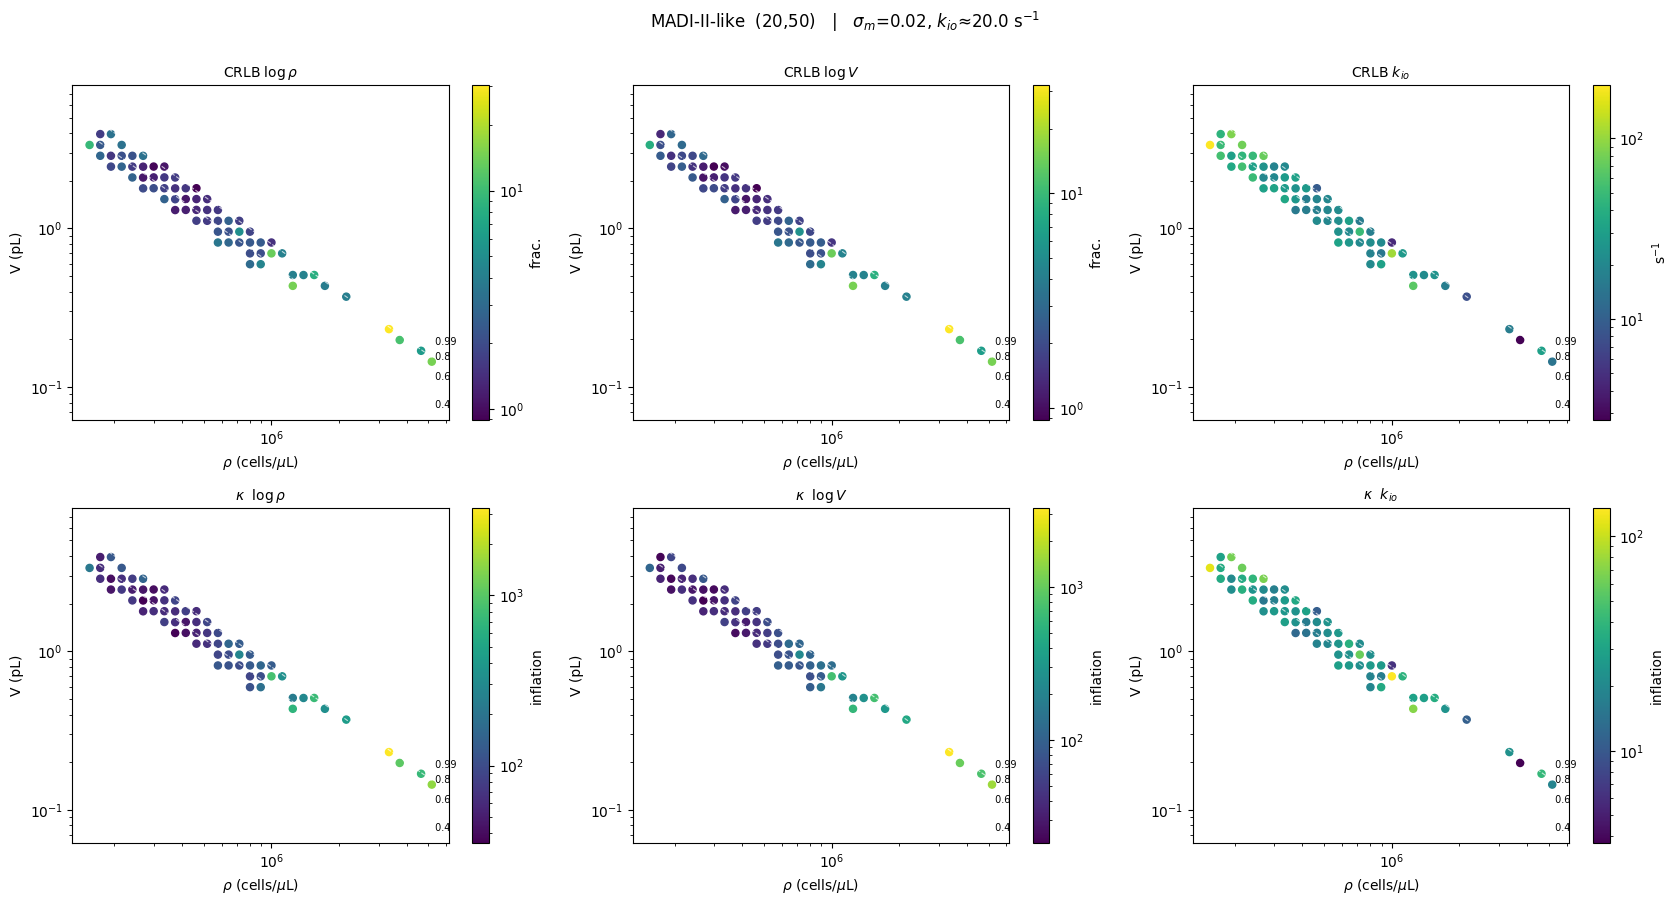

In [13]:
# ═══════════════════════════════════════════════════════════
# Cell 8 — CRLB and kappa maps over the (rho, V) plane
# ═══════════════════════════════════════════════════════════
def plane_scatter(res, values, title, cbar_label, log_color=True, ax=None):
    ax = ax or plt.gca()
    x = [r.rho for r in res]; y = [r.V for r in res]
    sc = ax.scatter(x, y, c=values, s=26,
                    norm=plt.matplotlib.colors.LogNorm() if log_color else None,
                    cmap="viridis")
    # constant-v_i hyperbolae
    rr = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
    for vi in (0.40, 0.60, 0.80, 0.99):
        ax.plot(rr, vi/(rr*1e-6), "w--", lw=0.8, alpha=0.7)
        ax.text(rr[-1], vi/(rr[-1]*1e-6), f" {vi}", color="k", fontsize=7, va="center")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\rho$ (cells/$\mu$L)"); ax.set_ylabel("V (pL)")
    ax.set_title(title, fontsize=10)
    plt.colorbar(sc, ax=ax, label=cbar_label)
    return ax

name = "MADI-II-like  (20,50)"
res = results[name]
crl = np.array([r.crlb for r in res]); kap = np.array([r.kappa for r in res])

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for p, (lab, unit) in enumerate([(r"$\log\rho$","frac."), (r"$\log V$","frac."),
                                  (r"$k_{io}$","s$^{-1}$")]):
    plane_scatter(res, crl[:, p], f"CRLB {lab}", unit, ax=axes[0, p])
    plane_scatter(res, kap[:, p], rf"$\kappa$  {lab}", "inflation", ax=axes[1, p])
fig.suptitle(f"{name}   |   $\\sigma_m$={SIGMA}, $k_{{io}}$≈{KIO_TARGET} s$^{{-1}}$", y=1.00)
plt.tight_layout(); plt.show()

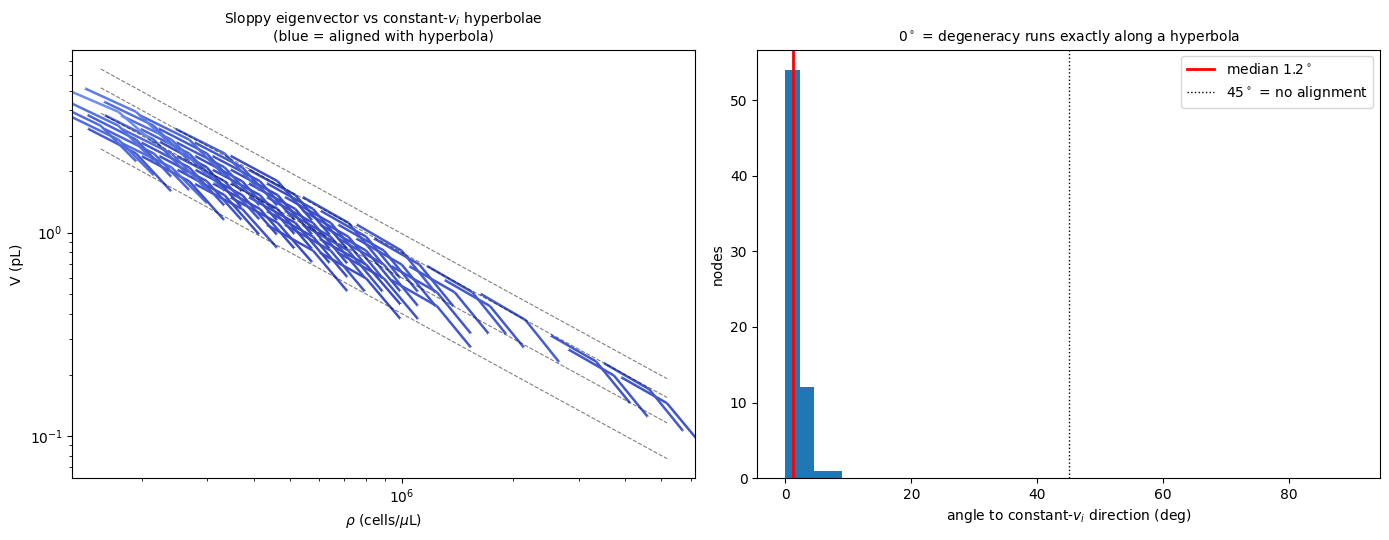

median angle to hyperbola : 1.21 deg
fraction within 15 deg    : 100.0%
median condition number   : 3.33e+04

worst-column beta: median 2.861e-03, max 8.278e-01
  (uncorrected Fisher inflation would be 1+beta)


In [17]:
# ═══════════════════════════════════════════════════════════
# Cell 9 — The structural figure: does the sloppy direction
#          follow the constant-v_i hyperbolae?
#
# Hypothesis: <A/V> = (rho/1e9)^(1/3) * g(v_i). Moving ALONG a
# hyperbola holds v_i (and so g) fixed and changes <A/V> only via
# the weak rho^(1/3) prefactor — one full rho node moves it just
# 1.116^(1/3)-1 = 3.7%. Membrane encounter rate is what the signal
# is most sensitive to, so the curve barely moves along that
# direction. That is a degeneracy with a mechanism.
#
# If the hypothesis holds, the segments below visibly lie along
# the dashed hyperbolae.
# ═══════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.array([r.rho for r in res]); y = np.array([r.V for r in res])
ang = np.array([r.sloppy_angle_deg for r in res])
vec = np.array([r.sloppy_vec for r in res])

# quiver in log-log space: a unit step in (log rho, log V)
L = 0.5
u = x * (np.exp(L*vec[:, 0]) - 1)
v = y * (np.exp(L*vec[:, 1]) - 1)
ax1.quiver(x, y, u, v, ang, cmap="coolwarm", clim=(0, 45),
           angles="xy", scale_units="xy", scale=1, width=0.004, headwidth=0)
ax1.quiver(x, y, -u, -v, ang, cmap="coolwarm", clim=(0, 45),
           angles="xy", scale_units="xy", scale=1, width=0.004, headwidth=0)
rr = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
for vi in (0.40, 0.60, 0.80, 0.99):
    ax1.plot(rr, vi/(rr*1e-6), "k--", lw=0.8, alpha=0.5)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$\rho$ (cells/$\mu$L)"); ax1.set_ylabel("V (pL)")
ax1.set_title("Sloppy eigenvector vs constant-$v_i$ hyperbolae\n"
              "(blue = aligned with hyperbola)", fontsize=10)

ax2.hist(ang, bins=40, range=(0, 90))
ax2.axvline(np.median(ang), color="r", lw=2,
            label=f"median {np.median(ang):.1f}$^\\circ$")
ax2.axvline(45, color="k", ls=":", lw=1, label="45$^\\circ$ = no alignment")
ax2.set_xlabel("angle to constant-$v_i$ direction (deg)")
ax2.set_ylabel("nodes"); ax2.legend()
ax2.set_title("0$^\\circ$ = degeneracy runs exactly along a hyperbola", fontsize=10)
plt.tight_layout(); plt.show()

print(f"median angle to hyperbola : {np.median(ang):.2f} deg")
print(f"fraction within 15 deg    : {(ang < 15).mean():.1%}")
print(f"median condition number   : {np.median([r.cond for r in res]):.3g}")
if HAS_VAR:
    bm = np.array([r.beta_max for r in res])
    print(f"\nworst-column beta: median {np.nanmedian(bm):.3e}, max {np.nanmax(bm):.3e}")
    print("  (uncorrected Fisher inflation would be 1+beta)")

In [15]:
# ═══════════════════════════════════════════════════════════
# Cell 10 — Single-Delta vs multi-Delta at MATCHED column count
#
# The fair comparison is at equal total measurements, i.e. equal
# scan time, not equal number of (delta,Delta) pairs. We subsample
# the multi-Delta protocols down to the single-Delta column count.
# ═══════════════════════════════════════════════════════════
rng = np.random.default_rng(0)
base_cols = select_columns(PROTOCOLS["MADI-II-like  (20,50)"])
N_MATCH = len(base_cols)

rows = []
for name, pairs in PROTOCOLS.items():
    cols = select_columns(pairs)
    if len(cols) > N_MATCH:
        cols = np.sort(rng.choice(cols, N_MATCH, replace=False))
    elif len(cols) < N_MATCH:
        rows.append((name, len(cols), np.nan, np.nan, np.nan)); continue
    r = sweep(cols, SIGMA, KIO_TARGET)
    if not r:
        rows.append((name, len(cols), np.nan, np.nan, np.nan)); continue
    c = np.array([x.crlb for x in r]); k = np.array([x.kappa for x in r])
    rows.append((name, len(cols), np.median(c[:,2]), np.median(k[:,2]),
                 np.median([x.sloppy_angle_deg for x in r])))

print(f"{'protocol':26s} {'cols':>5s} {'CRLB kio':>10s} {'kappa kio':>10s} {'angle':>7s}")
print("-"*64)
for nm, nc, ck, kk, an in rows:
    print(f"{nm:26s} {nc:5d} {ck:10.3f} {kk:10.2f} {an:6.1f}d")
print("\nPredicted headline: k_io is weakly determined at a single Delta and")
print("improves substantially with multi-Delta at matched cost. A null result")
print("here is equally publishable — it would vindicate the single-Delta design")
print("used in all three MADI papers.")

protocol                    cols   CRLB kio  kappa kio   angle
----------------------------------------------------------------
MADI-II-like  (20,50)         10     24.097      23.77    1.2d
MADI-III-like (7,25)           1        nan        nan    nand
multi-D  (20,25/50/80)        10      2.599       2.73    3.4d
multi-d  (7/15/30, 50)        10      8.542       9.41    1.5d

Predicted headline: k_io is weakly determined at a single Delta and
improves substantially with multi-Delta at matched cost. A null result
here is equally publishable — it would vindicate the single-Delta design
used in all three MADI papers.


In [18]:
# ═══════════════════════════════════════════════════════════
# Cell 11 — Map main columns into the diagnostic subset
# ═══════════════════════════════════════════════════════════
sub_del = np.asarray(raw["ensemble_subset_pair_deltas"]).astype(int)
sub_Del = np.asarray(raw["ensemble_subset_pair_Deltas"]).astype(int)
sub_b   = np.asarray(raw["ensemble_subset_b_values"]).astype(float)
sub_nb  = int(np.asarray(raw["ensemble_subset_n_b"]))
ens_sub = np.asarray(raw["ensemble_means_subset"], dtype=np.float64)
N_ENS   = ens_sub.shape[1]

print(f"subset: {len(sub_del)} pairs x {sub_nb} b = {len(sub_del)*sub_nb} cols, "
      f"{N_ENS} ensembles")
print("subset pairs:", list(zip(sub_del, sub_Del)))

sub_key = {(int(sub_del[p]), int(sub_Del[p]), float(sub_b[bi])): p*sub_nb + bi
           for p in range(len(sub_del)) for bi in range(sub_nb)}
main_to_sub = np.full(n_columns, -1, dtype=int)
for c in range(n_columns):
    main_to_sub[c] = sub_key.get((int(col_del[c]), int(col_Del[c]), float(col_b[c])), -1)

for name, pairs in PROTOCOLS.items():
    cols = select_columns(pairs)
    cov_frac = (main_to_sub[cols] >= 0).mean() if len(cols) else np.nan
    print(f"{name:26s} {len(cols):3d} cols, {100*cov_frac:5.1f}% have covariance")

subset: 8 pairs x 25 b = 200 cols, 40 ensembles
subset pairs: [(np.int64(5), np.int64(15)), (np.int64(7), np.int64(25)), (np.int64(10), np.int64(30)), (np.int64(12), np.int64(36)), (np.int64(15), np.int64(40)), (np.int64(20), np.int64(50)), (np.int64(25), np.int64(60)), (np.int64(30), np.int64(80))]
MADI-II-like  (20,50)       10 cols, 100.0% have covariance
MADI-III-like (7,25)         1 cols, 100.0% have covariance
multi-D  (20,25/50/80)      26 cols,  38.5% have covariance
multi-d  (7/15/30, 50)      21 cols,   0.0% have covariance


In [19]:
# ═══════════════════════════════════════════════════════════
# Cell 12 — node_fisher v2: real covariance + dropout reasons
#
# Var(J) = [Var(S+) + Var(S-) - 2 Cov(S+,S-)] / h^2, all on the
# ENTRY MEAN scale (divide ensemble-level moments by n_ens).
# Positive covariance is the payoff from shared random numbers;
# assuming zero throws that away and over-corrects.
# ═══════════════════════════════════════════════════════════
from collections import Counter
DROP = Counter()

def node_fisher2(i, j, k, cols, sigma_m, kstencil=1, correct_bias=True, use_cov=True):
    e0 = lookup.get((i, j, k))
    if e0 is None:
        DROP["centre missing"] += 1; return None

    sub = main_to_sub[cols]
    J = np.empty((len(cols), 3)); varJ = np.zeros((len(cols), 3))

    for p, (axis, d) in enumerate(AXES.items()):
        lo = lookup.get((i-kstencil*d[0], j-kstencil*d[1], k-kstencil*d[2]))
        hi = lookup.get((i+kstencil*d[0], j+kstencil*d[1], k+kstencil*d[2]))
        if lo is None or hi is None:
            DROP[f"stencil missing: {axis}"] += 1; return None

        if   axis == "rho": h = np.log(rhos[hi]) - np.log(rhos[lo])
        elif axis == "V":   h = np.log(Vs[hi])   - np.log(Vs[lo])
        else:               h = kios[hi] - kios[lo]
        J[:, p] = (vectors[hi, cols] - vectors[lo, cols]) / h

        if HAS_VAR:
            v_hi = signal_variance[hi, cols] / N_ENS
            v_lo = signal_variance[lo, cols] / N_ENS
            cov  = np.zeros(len(cols))
            if use_cov:
                m = sub >= 0
                if m.any():
                    a = ens_sub[hi][:, sub[m]]          # (n_ens, n_avail)
                    b_ = ens_sub[lo][:, sub[m]]
                    cov[m] = ((a - a.mean(0)) * (b_ - b_.mean(0))).sum(0) / (N_ENS - 1) / N_ENS
            varJ[:, p] = np.maximum(v_hi + v_lo - 2*cov, 0.0) / (h*h)

    F = fim_from_jacobian(J, sigma_m)
    if correct_bias and HAS_VAR:
        F = F - np.diag((varJ / sigma_m[:, None]**2).sum(axis=0))
    if np.any(np.linalg.eigvalsh(F) <= 0):
        DROP["not positive definite"] += 1; return None

    C = np.linalg.inv(F)
    crlb = np.sqrt(np.diag(C)); kappa = np.sqrt(np.diag(C)*np.diag(F))
    w, Vec = np.linalg.eigh(C[:2, :2]); sloppy = Vec[:, np.argmax(w)]
    ang = np.degrees(np.arccos(np.clip(abs(sloppy @ (np.array([1.,-1.])/np.sqrt(2))), 0, 1)))
    scale = np.diag([1., 1., max(kios[e0], 1.)])
    with np.errstate(divide="ignore", invalid="ignore"):
        beta_max = np.nanmax(varJ / J**2)
    DROP["kept"] += 1
    return NodeResult(i, j, k, rhos[e0], Vs[e0], kios[e0], rhos[e0]*Vs[e0]*1e-6,
                      F, C, crlb, kappa, sloppy, ang,
                      np.linalg.cond(scale @ F @ scale), beta_max)

def sweep2(cols, sigma_level=0.02, kio_target=20.0, kstencil=1, use_cov=True):
    DROP.clear()
    sigma_m = np.full(len(cols), sigma_level)
    k = int(np.argmin(np.abs(kio_grid - kio_target)))
    out = [r for (i, j) in sorted(set(zip(i_rho, j_V)))
           if (r := node_fisher2(i, j, k, cols, sigma_m, kstencil, use_cov=use_cov)) is not None]
    return out, dict(DROP)

In [20]:
# ═══════════════════════════════════════════════════════════
# Cell 13 — Cov=0 vs real Cov, on the protocol fully inside
#           the diagnostic subset
# ═══════════════════════════════════════════════════════════
cols = select_columns(PROTOCOLS["MADI-II-like  (20,50)"])
for use_cov in (False, True):
    res, drops = sweep2(cols, SIGMA, KIO_TARGET, use_cov=use_cov)
    c = np.array([r.crlb for r in res]); kp = np.array([r.kappa for r in res])
    bm = np.array([r.beta_max for r in res])
    print(f"\n{'REAL Cov' if use_cov else 'Cov = 0':>10s}: {len(res)} nodes")
    print(f"  median CRLB logV = {np.median(c[:,1]):.4f}   "
          f"median kappa_rho = {np.median(kp[:,0]):.2f}   "
          f"median beta_max = {np.median(bm):.3e}")
    print(f"  dropouts: {drops}")


   Cov = 0: 68 nodes
  median CRLB logV = 2.0329   median kappa_rho = 89.50   median beta_max = 2.861e-03
  dropouts: {'stencil missing: rho': 68, 'not positive definite': 82, 'stencil missing: V': 24, 'kept': 68}

  REAL Cov: 95 nodes
  median CRLB logV = 1.5246   median kappa_rho = 65.67   median beta_max = 3.805e-04
  dropouts: {'stencil missing: rho': 68, 'kept': 95, 'not positive definite': 55, 'stencil missing: V': 24}


In [21]:
# ═══════════════════════════════════════════════════════════
# Cell 14 — MADI-III at preclinical gradient limits
# ═══════════════════════════════════════════════════════════
for Gmax in (0.080, 0.300, 1.000):
    cols = select_columns([(7, 25)], G_max=Gmax)
    if len(cols) < 3:
        print(f"G_max={Gmax*1e3:6.0f} mT/m: {len(cols)} cols (too few)"); continue
    res, drops = sweep2(cols, SIGMA, KIO_TARGET)
    if not res:
        print(f"G_max={Gmax*1e3:6.0f} mT/m: {len(cols)} cols, 0 nodes {drops}"); continue
    kp = np.array([r.kappa for r in res]); c = np.array([r.crlb for r in res])
    print(f"G_max={Gmax*1e3:6.0f} mT/m: {len(cols):2d} cols, {len(res):3d} nodes, "
          f"kappa_kio={np.median(kp[:,2]):6.2f}, CRLB logV={np.median(c[:,1]):.3f}")

G_max=    80 mT/m: 1 cols (too few)
G_max=   300 mT/m: 10 cols, 117 nodes, kappa_kio= 13.99, CRLB logV=0.898
G_max=  1000 mT/m: 10 cols, 117 nodes, kappa_kio= 13.99, CRLB logV=0.898


In [24]:
# ═══════════════════════════════════════════════════════════
# Cell 15 — Comparison harness
#
# Collects results keyed by (i,j) so protocols can be compared
# node-by-node on a common set, and matches column counts so
# every comparison is at equal scan time.
# ═══════════════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# use the covariance-aware node function if Cell 12 was run
try:
    _nf, _USE_COV = node_fisher2, True
except NameError:
    _nf, _USE_COV = node_fisher, False
print(f"node function: {'node_fisher2 (real covariance)' if _USE_COV else 'node_fisher (Cov=0)'}")

LN10 = np.log(10.0)
RNG_SEED = 0

def collect(cols, sigma=0.02, kio_target=20.0, kstencil=1):
    """Returns {(i,j): NodeResult} plus a dropout tally."""
    sigma_m = np.full(len(cols), sigma)
    k = int(np.argmin(np.abs(kio_grid - kio_target)))
    out, n_try = {}, 0
    try: DROP.clear()
    except NameError: pass
    for (i, j) in sorted(set(zip(i_rho, j_V))):
        n_try += 1
        r = (_nf(i, j, k, cols, sigma_m, kstencil, use_cov=True) if _USE_COV
             else _nf(i, j, k, cols, sigma_m, kstencil))
        if r is not None:
            out[(i, j)] = r
    return out, n_try

def matched_cols(pairs, n_match, seed=RNG_SEED, **kw):
    """Subsample a protocol's columns to n_match for equal-scan-time comparison."""
    c = select_columns(pairs, **kw)
    if len(c) <= n_match:
        return c
    return np.sort(np.random.default_rng(seed).choice(c, n_match, replace=False))

# reference: the single-Delta protocol sets the budget
BASE_PAIRS = [(20, 50)]
N_MATCH = len(select_columns(BASE_PAIRS))
print(f"matched column budget: {N_MATCH} columns\n")

FAMILIES = {
    "single Δ (20,50)":        [(20, 50)],
    "multi-Δ (20; 25/50/80)":  [(20, 25), (20, 50), (20, 80)],
    "multi-δ (7/15/30; 50)":   [(7, 50), (15, 50), (30, 50)],
}

nodes, tallies = {}, {}
for name, pairs in FAMILIES.items():
    cols = matched_cols(pairs, N_MATCH)
    nd, n_try = collect(cols)
    nodes[name] = nd
    tallies[name] = (len(nd), n_try, len(cols))
    tD = [D - d/3 for d, D in pairs]
    print(f"{name:26s} {len(cols):3d} cols  {len(nd):3d}/{n_try} nodes  "
          f"t_D {min(tD):5.1f}–{max(tD):5.1f} ms (span {max(tD)/min(tD):.2f}×)")

COMMON = set.intersection(*[set(d) for d in nodes.values()])
print(f"\ncommon nodes across all three protocols: {len(COMMON)}")

node function: node_fisher2 (real covariance)
matched column budget: 10 columns

single Δ (20,50)            10 cols   95/242 nodes  t_D  43.3– 43.3 ms (span 1.00×)
multi-Δ (20; 25/50/80)      10 cols  150/242 nodes  t_D  18.3– 73.3 ms (span 4.00×)
multi-δ (7/15/30; 50)       10 cols  114/242 nodes  t_D  40.0– 47.7 ms (span 1.19×)

common nodes across all three protocols: 85


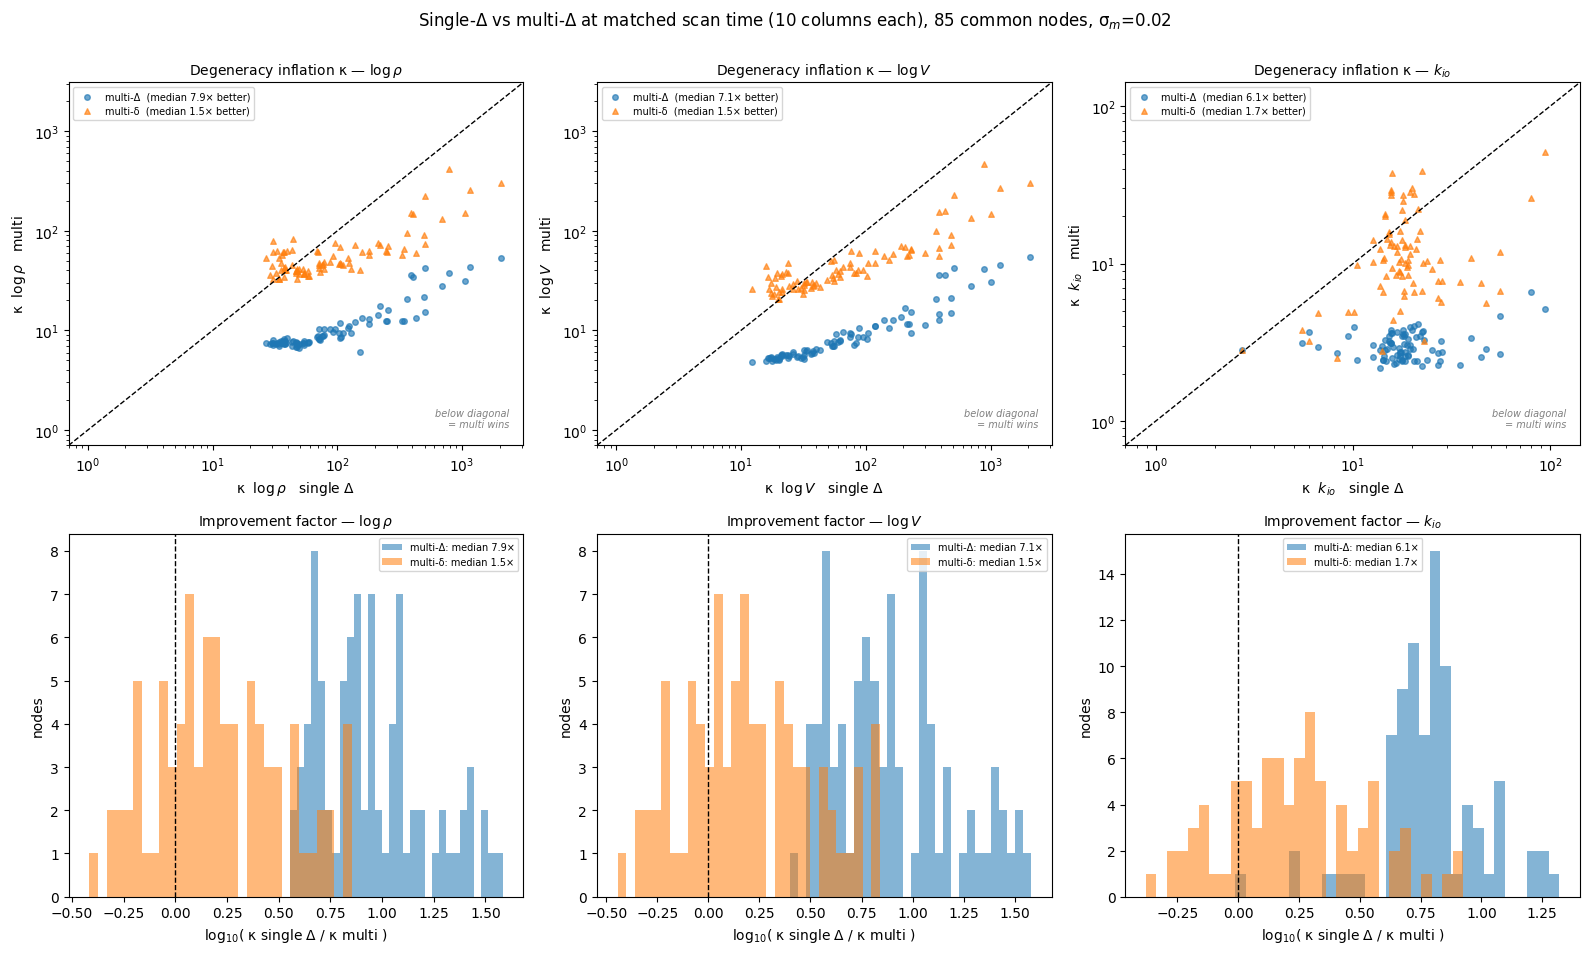

parameter      κ single   κ multi-Δ   κ multi-δ    gain Δ    gain δ
--------------------------------------------------------------------
log rho            70.7         8.2        48.0      7.9×      1.5×
log V              54.2         7.2        37.8      7.1×      1.5×
k_io               17.8         2.9        10.5      6.1×      1.7×


In [25]:
# ═══════════════════════════════════════════════════════════
# FIGURE 1 — The headline: paired node-by-node comparison
#
# Every point is one (rho,V) node evaluated under two protocols
# at IDENTICAL scan time. Points above the diagonal are nodes
# where multi-Delta wins. This removes the selection effect in
# the summary table, which compared different node sets.
# ═══════════════════════════════════════════════════════════
common = sorted(COMMON)
base = "single Δ (20,50)"
alts = ["multi-Δ (20; 25/50/80)", "multi-δ (7/15/30; 50)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
PARAM = [(0, r"$\log\rho$"), (1, r"$\log V$"), (2, r"$k_{io}$")]

for col, (p, lab) in enumerate(PARAM):
    ax = axes[0, col]
    x = np.array([nodes[base][n].kappa[p] for n in common])
    for alt, c, mk in zip(alts, ["tab:blue", "tab:orange"], ["o", "^"]):
        y = np.array([nodes[alt][n].kappa[p] for n in common])
        ax.scatter(x, y, s=16, alpha=0.65, c=c, marker=mk,
                   label=f"{alt.split()[0]}  (median {np.median(x/y):.1f}× better)")
    lim = [min(x.min(), 1)*0.7, x.max()*1.5]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"κ  {lab}   single Δ"); ax.set_ylabel(f"κ  {lab}   multi")
    ax.set_title(f"Degeneracy inflation κ — {lab}", fontsize=10)
    ax.legend(fontsize=7, loc="upper left")
    ax.text(0.97, 0.05, "below diagonal\n= multi wins", transform=ax.transAxes,
            ha="right", fontsize=7, style="italic", color="gray")

    ax2 = axes[1, col]
    for alt, c in zip(alts, ["tab:blue", "tab:orange"]):
        ratio = x / np.array([nodes[alt][n].kappa[p] for n in common])
        ax2.hist(np.log10(ratio), bins=30, alpha=0.55, color=c,
                 label=f"{alt.split()[0]}: median {np.median(ratio):.1f}×")
    ax2.axvline(0, color="k", ls="--", lw=1)
    ax2.set_xlabel(f"log$_{{10}}$( κ single Δ / κ multi )")
    ax2.set_ylabel("nodes"); ax2.legend(fontsize=7)
    ax2.set_title(f"Improvement factor — {lab}", fontsize=10)

fig.suptitle(f"Single-Δ vs multi-Δ at matched scan time ({N_MATCH} columns each), "
             f"{len(common)} common nodes, σ$_m$={SIGMA}", y=1.00)
plt.tight_layout(); plt.show()

print(f"{'parameter':12s} {'κ single':>10s} {'κ multi-Δ':>11s} {'κ multi-δ':>11s} "
      f"{'gain Δ':>9s} {'gain δ':>9s}")
print("-"*68)
for p, lab in [(0,"log rho"), (1,"log V"), (2,"k_io")]:
    ks = np.array([nodes[base][n].kappa[p] for n in common])
    kD = np.array([nodes[alts[0]][n].kappa[p] for n in common])
    kd = np.array([nodes[alts[1]][n].kappa[p] for n in common])
    print(f"{lab:12s} {np.median(ks):10.1f} {np.median(kD):11.1f} {np.median(kd):11.1f} "
          f"{np.median(ks/kD):8.1f}× {np.median(ks/kd):8.1f}×")

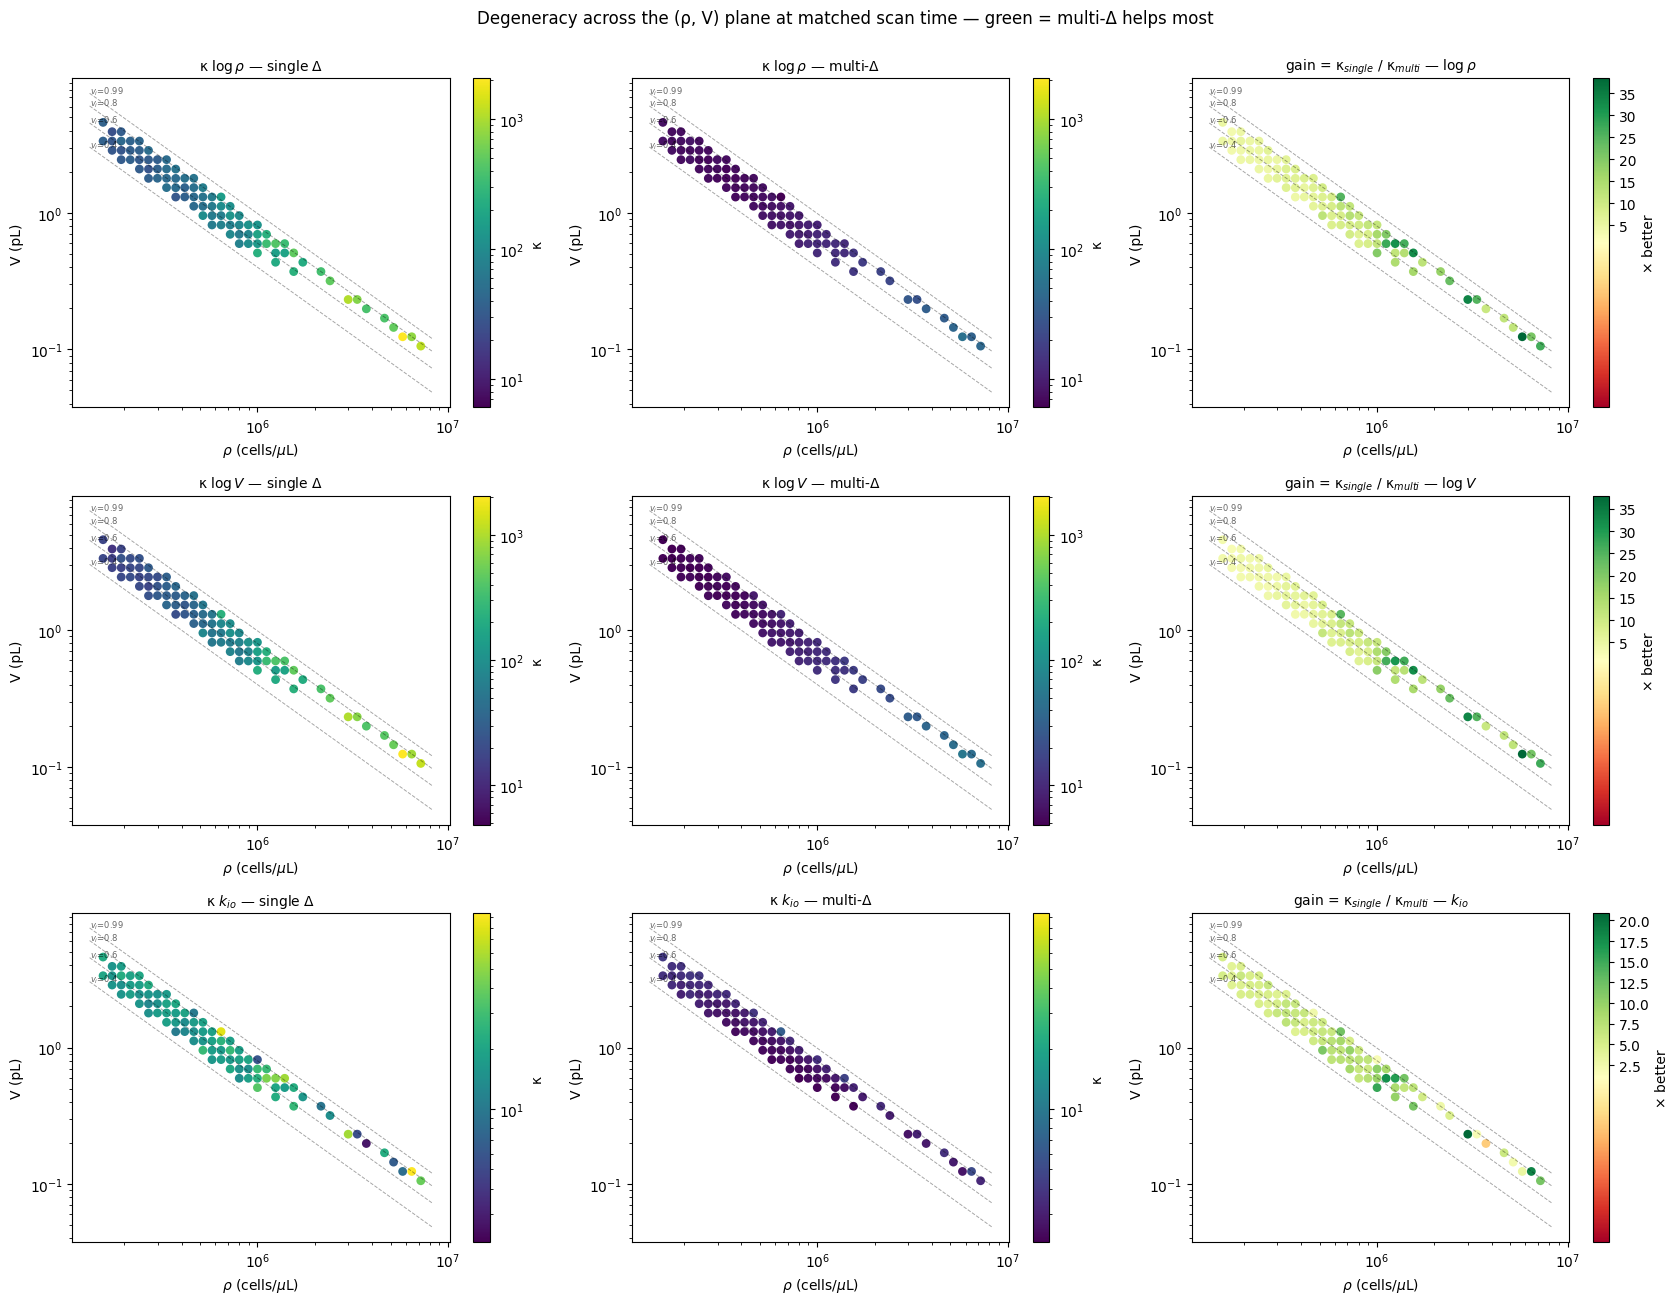

In [26]:
# ═══════════════════════════════════════════════════════════
# FIGURE 2 — How the picture changes across parameter space
#
# Same quantity, same scan time, three views: single Δ, multi Δ,
# and their ratio. The ratio panel answers "where does multi-Δ
# actually buy you something."
# ═══════════════════════════════════════════════════════════
def plane(ax, keys, vals, title, cbar, cmap="viridis", norm=None, hyper=True):
    x = np.array([nodes[base][k].rho for k in keys])
    y = np.array([nodes[base][k].V   for k in keys])
    sc = ax.scatter(x, y, c=vals, s=40, cmap=cmap, norm=norm, edgecolor="none")
    if hyper:
        rr = np.logspace(np.log10(x.min()*0.85), np.log10(x.max()*1.15), 200)
        for vi in (0.40, 0.60, 0.80, 0.99):
            ax.plot(rr, vi/(rr*1e-6), "k--", lw=0.7, alpha=0.35)
            ax.annotate(f"$v_i$={vi}", (rr[0], vi/(rr[0]*1e-6)), fontsize=6,
                        color="k", alpha=0.6)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\rho$ (cells/$\mu$L)"); ax.set_ylabel("V (pL)")
    ax.set_title(title, fontsize=10)
    plt.colorbar(sc, ax=ax, label=cbar)

from matplotlib.colors import LogNorm, TwoSlopeNorm
alt = alts[0]

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
for row, (p, lab) in enumerate(PARAM):
    ks = np.array([nodes[base][n].kappa[p] for n in common])
    kD = np.array([nodes[alt][n].kappa[p]  for n in common])
    lo, hi = min(ks.min(), kD.min()), max(ks.max(), kD.max())
    nrm = LogNorm(vmin=lo, vmax=hi)
    plane(axes[row,0], common, ks, f"κ {lab} — single Δ", "κ", norm=nrm)
    plane(axes[row,1], common, kD, f"κ {lab} — multi-Δ",  "κ", norm=nrm)
    gain = ks/kD
    plane(axes[row,2], common, gain, f"gain = κ$_{{single}}$ / κ$_{{multi}}$ — {lab}",
          "× better", cmap="RdYlGn",
          norm=TwoSlopeNorm(vmin=min(gain.min(), 0.9), vcenter=1.0, vmax=gain.max()))
fig.suptitle("Degeneracy across the (ρ, V) plane at matched scan time "
             "— green = multi-Δ helps most", y=1.00)
plt.tight_layout(); plt.show()

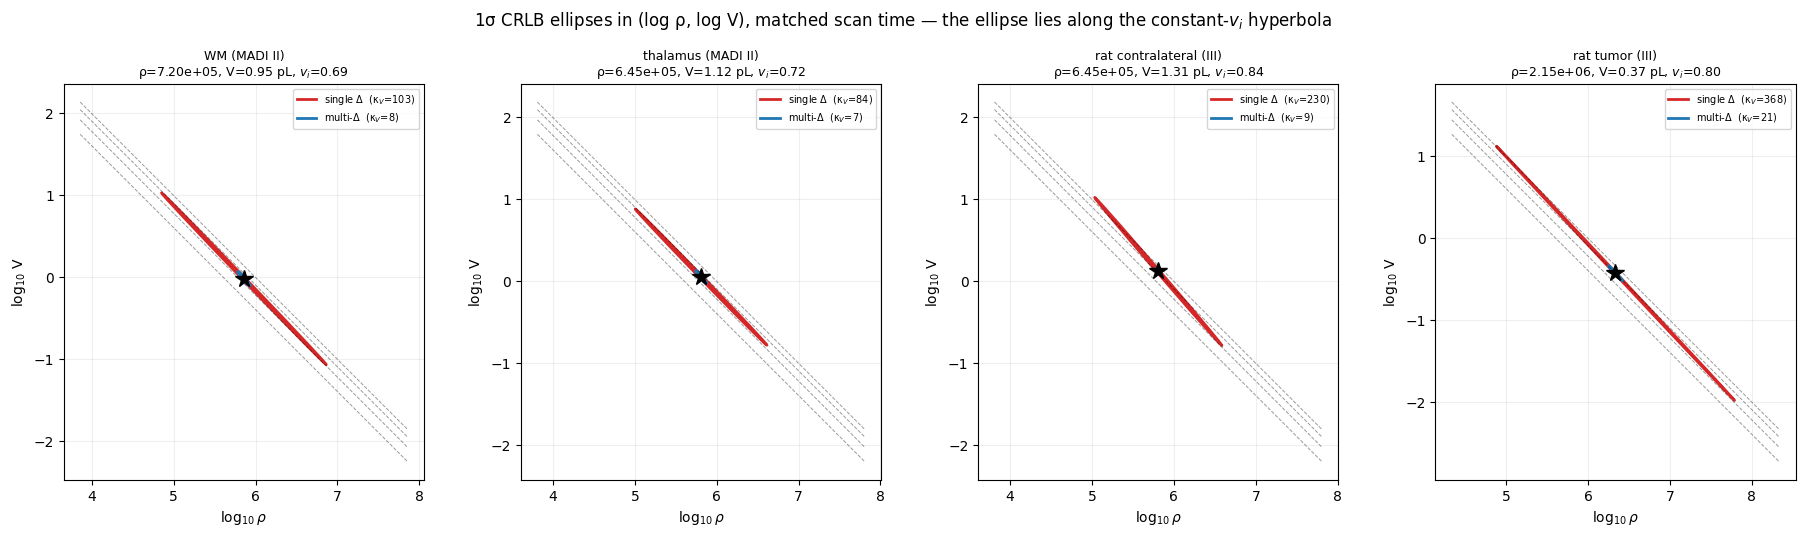

In [27]:
# ═══════════════════════════════════════════════════════════
# FIGURE 3 — The intuitive one: CRLB confidence ellipses
#
# The 2x2 (log rho, log V) block of C = F^-1 is the marginalized
# covariance. Its 1-sigma ellipse is the region the data cannot
# distinguish. Elongation along a constant-v_i hyperbola IS the
# degeneracy, drawn to scale.
#
# Note: CRLB is in natural log; divide by ln(10) for log10 axes,
# so the covariance divides by ln(10)^2.
# ═══════════════════════════════════════════════════════════
def ellipse(C2, centre_log10, nsig=1.0, n=240):
    w, Vec = np.linalg.eigh(C2 / LN10**2)
    t = np.linspace(0, 2*np.pi, n)
    pts = Vec @ (np.sqrt(np.maximum(w, 0))[:, None] * np.stack([np.cos(t), np.sin(t)]))
    return centre_log10[0] + nsig*pts[0], centre_log10[1] + nsig*pts[1]

# literature tissue anchors; snapped to the nearest available node
ANCHORS = {
    "WM (MADI II)":            (6.9e5, 0.91),
    "thalamus (MADI II)":      (6.2e5, 1.20),
    "rat contralateral (III)": (1.04e6, 2.00),
    "rat tumor (III)":         (2.75e6, 0.46),
}
def nearest_node(rho_t, V_t):
    d = {k: (np.log(nodes[base][k].rho/rho_t)**2 + np.log(nodes[base][k].V/V_t)**2)
         for k in common}
    return min(d, key=d.get)

fig, axes = plt.subplots(1, len(ANCHORS), figsize=(4.6*len(ANCHORS), 5.0))
for ax, (label, (rt, Vt)) in zip(np.atleast_1d(axes), ANCHORS.items()):
    key = nearest_node(rt, Vt)
    c0 = np.array([np.log10(nodes[base][key].rho), np.log10(nodes[base][key].V)])
    for nm, col in [(base, "tab:red"), (alt, "tab:blue")]:
        ex, ey = ellipse(nodes[nm][key].C[:2, :2], c0)
        ax.plot(ex, ey, color=col, lw=2,
                label=f"{nm.split('(')[0].strip()}  (κ$_V$={nodes[nm][key].kappa[1]:.0f})")
        ax.fill(ex, ey, color=col, alpha=0.12)
    for vi in (0.40, 0.60, 0.80, 0.99):
        rr = np.logspace(c0[0]-2, c0[0]+2, 100)
        ax.plot(np.log10(rr), np.log10(vi/(rr*1e-6)), "k--", lw=0.7, alpha=0.4)
    ax.plot(*c0, "k*", ms=13, zorder=5)
    ax.set_xlabel(r"log$_{10}\,\rho$"); ax.set_ylabel(r"log$_{10}$ V")
    ax.set_title(f"{label}\nρ={nodes[base][key].rho:.2e}, V={nodes[base][key].V:.2f} pL, "
                 f"$v_i$={nodes[base][key].vi:.2f}", fontsize=9)
    ax.set_aspect("equal"); ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.2)
fig.suptitle("1σ CRLB ellipses in (log ρ, log V), matched scan time — "
             "the ellipse lies along the constant-$v_i$ hyperbola", y=1.02)
plt.tight_layout(); plt.show()

  skip single Δ=50: only 4 feasible columns


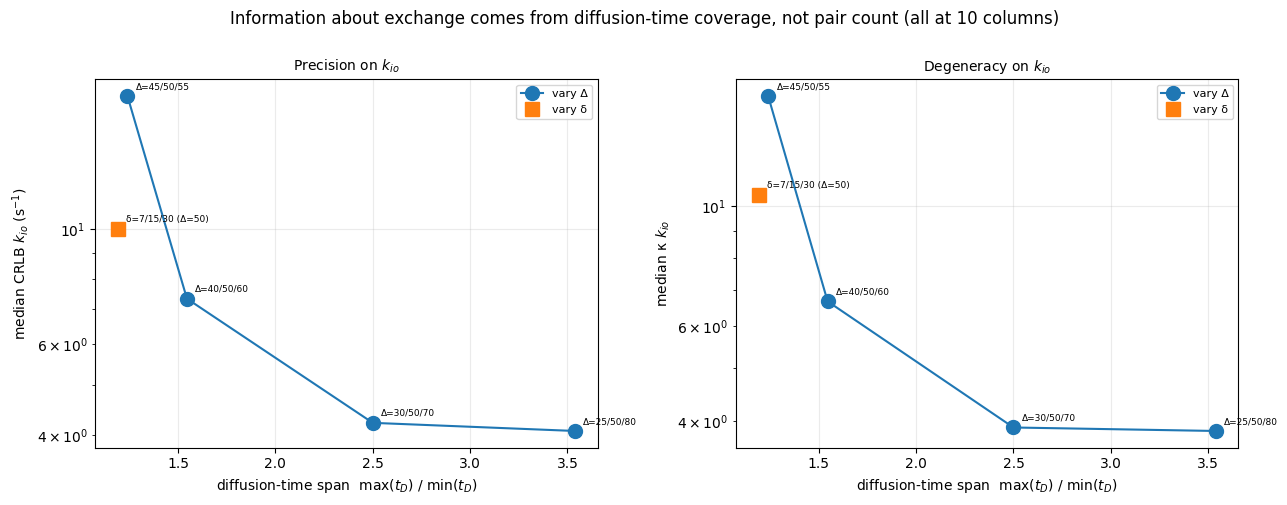


protocol                t_D span   CRLB kio    κ kio  CRLB logV  nodes
------------------------------------------------------------------------
Δ=45/50/55                 1.24×      18.09    15.98      2.073     65
Δ=40/50/60                 1.55×       7.34     6.66      0.826     85
Δ=30/50/70                 2.50×       4.23     3.89      0.591     85
Δ=25/50/80                 3.54×       4.08     3.83      0.621     85
δ=7/15/30 (Δ=50)           1.19×      10.02    10.47      1.099     85


In [32]:
# ═══════════════════════════════════════════════════════════
# FIGURE 4 — The mechanism: it is the diffusion-time SPAN
#
# Families of three (delta,Delta) pairs with progressively wider
# t_D coverage, all subsampled to the same column budget. If the
# mechanism is time-dependence, CRLB(k_io) should track the span,
# not the number of pairs.
# ═══════════════════════════════════════════════════════════
SPANS = {
    "single Δ=50":        [(10, 50)],
    "Δ=45/50/55":         [(10, 45), (10, 50), (10, 55)],
    "Δ=40/50/60":         [(10, 40), (10, 50), (10, 60)],
    "Δ=30/50/70":         [(10, 30), (10, 50), (10, 70)],
    "Δ=25/50/80":         [(10, 25), (10, 50), (10, 80)],
    "δ=7/15/30 (Δ=50)":   [(7, 50), (15, 50), (30, 50)],
}

rows = []
for nm, prs in SPANS.items():
    cols = matched_cols(prs, N_MATCH)
    if len(cols) < N_MATCH:
        print(f"  skip {nm}: only {len(cols)} feasible columns"); continue
    nd, _ = collect(cols)
    shared = sorted(set(nd) & COMMON)
    if not shared: continue
    tD = [D - d/3 for d, D in prs]
    rows.append((nm, max(tD)/min(tD),
                 np.median([nd[k].crlb[2]  for k in shared]),
                 np.median([nd[k].kappa[2] for k in shared]),
                 np.median([nd[k].crlb[1]  for k in shared]),
                 len(shared), "δ" if "δ" in nm else "Δ"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, idx, ylab, ttl in [(a1, 2, "median CRLB $k_{io}$ (s$^{-1}$)", "Precision on $k_{io}$"),
                            (a2, 3, "median κ $k_{io}$", "Degeneracy on $k_{io}$")]:
    for kind, c, mk in [("Δ", "tab:blue", "o"), ("δ", "tab:orange", "s")]:
        sel = [r for r in rows if r[6] == kind]
        if sel:
            ax.plot([r[1] for r in sel], [r[idx] for r in sel], mk, ms=10, color=c,
                    ls="-" if kind == "Δ" else "none",
                    label=f"vary {kind}")
    for r in rows:
        ax.annotate(r[0], (r[1], r[idx]), fontsize=6.5,
                    textcoords="offset points", xytext=(6, 5))
    ax.set_xlabel("diffusion-time span  max($t_D$) / min($t_D$)")
    ax.set_ylabel(ylab); ax.set_yscale("log"); ax.set_title(ttl, fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.suptitle(f"Information about exchange comes from diffusion-time coverage, "
             f"not pair count (all at {N_MATCH} columns)", y=1.00)
plt.tight_layout(); plt.show()

print(f"\n{'protocol':22s} {'t_D span':>9s} {'CRLB kio':>10s} {'κ kio':>8s} "
      f"{'CRLB logV':>10s} {'nodes':>6s}")
print("-"*72)
for nm, sp, ck, kk, cv, n, _ in rows:
    print(f"{nm:22s} {sp:8.2f}× {ck:10.2f} {kk:8.2f} {cv:10.3f} {n:6d}")

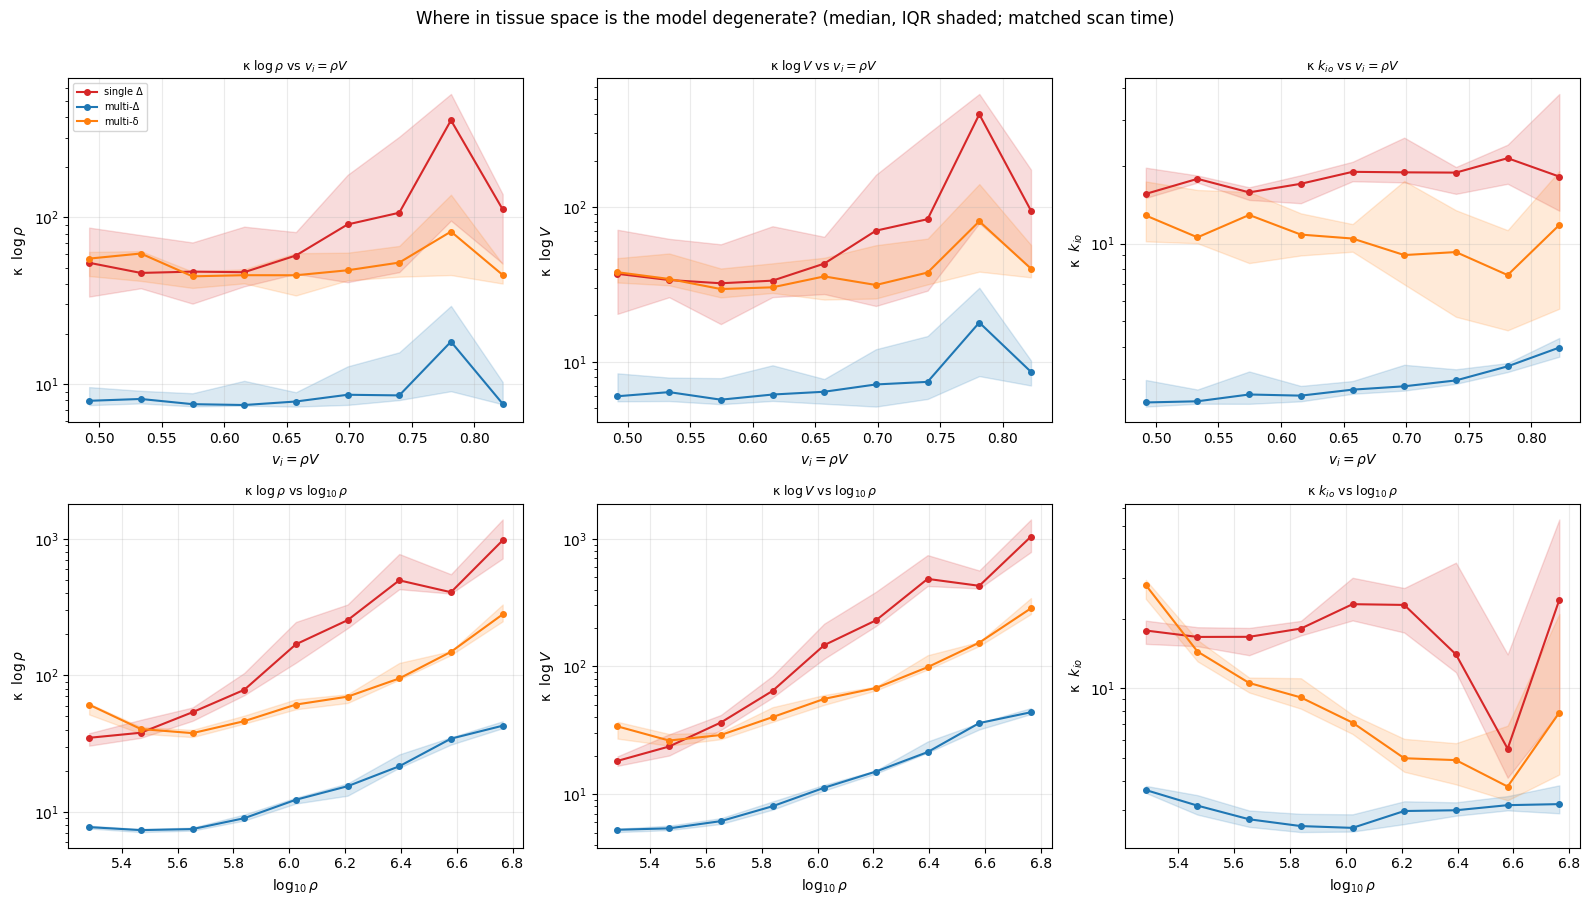

In [33]:
# ═══════════════════════════════════════════════════════════
# FIGURE 5 — Collapse onto the physically meaningful axes
#
# Because the degeneracy runs along constant-v_i hyperbolae, the
# 2D plane is nearly 1D. Profiling against v_i and rho separately
# shows WHERE in tissue space each protocol struggles.
# ═══════════════════════════════════════════════════════════
def binned(xv, yv, nb=9):
    edges = np.linspace(xv.min(), xv.max(), nb+1)
    ctr, med, q1, q3 = [], [], [], []
    for a, b_ in zip(edges[:-1], edges[1:]):
        m = (xv >= a) & (xv <= b_)
        if m.sum() >= 3:
            ctr.append(0.5*(a+b_)); med.append(np.median(yv[m]))
            q1.append(np.percentile(yv[m], 25)); q3.append(np.percentile(yv[m], 75))
    return map(np.array, (ctr, med, q1, q3))

vi_v  = np.array([nodes[base][n].vi for n in common])
rho_v = np.log10(np.array([nodes[base][n].rho for n in common]))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (p, lab) in enumerate(PARAM):
    for row, (xv, xlab) in enumerate([(vi_v, r"$v_i = \rho V$"),
                                       (rho_v, r"log$_{10}\,\rho$")]):
        ax = axes[row, col]
        for nm, c in [(base, "tab:red"), (alt, "tab:blue"), (alts[1], "tab:orange")]:
            yv = np.array([nodes[nm][n].kappa[p] for n in common])
            cx, md, q1, q3 = binned(xv, yv)
            ax.plot(cx, md, "-o", ms=4, color=c, label=nm.split("(")[0].strip())
            ax.fill_between(cx, q1, q3, color=c, alpha=0.16)
        ax.set_yscale("log"); ax.set_xlabel(xlab); ax.set_ylabel(f"κ  {lab}")
        ax.grid(alpha=0.25)
        if row == 0 and col == 0: ax.legend(fontsize=7)
        ax.set_title(f"κ {lab} vs {xlab}", fontsize=9)
fig.suptitle("Where in tissue space is the model degenerate? "
             "(median, IQR shaded; matched scan time)", y=1.00)
plt.tight_layout(); plt.show()

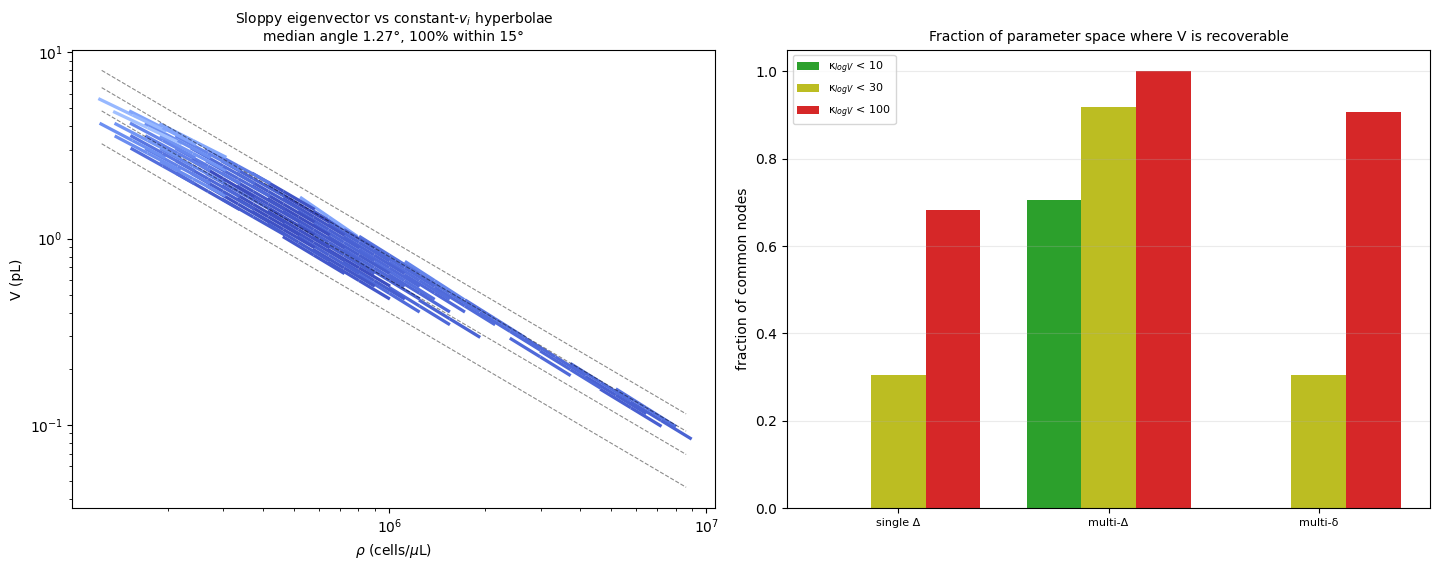

In [34]:
# ═══════════════════════════════════════════════════════════
# FIGURE 6 — Fixed structural figure (arrows were invisible at L=0.06)
#            plus protocol usability fractions
# ═══════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.8))

x = np.array([nodes[base][n].rho for n in common])
y = np.array([nodes[base][n].V   for n in common])
ang = np.array([nodes[base][n].sloppy_angle_deg for n in common])
vec = np.array([nodes[base][n].sloppy_vec for n in common])

L = 0.32                                    # long enough to actually see
for s in (+1, -1):
    ax1.quiver(x, y, x*(np.exp(s*L*vec[:,0])-1), y*(np.exp(s*L*vec[:,1])-1), ang,
               cmap="coolwarm", clim=(0, 20), angles="xy", scale_units="xy",
               scale=1, width=0.005, headwidth=0, headlength=0, headaxislength=0)
rr = np.logspace(np.log10(x.min()*0.8), np.log10(x.max()*1.2), 200)
for vi in (0.40, 0.60, 0.80, 0.99):
    ax1.plot(rr, vi/(rr*1e-6), "k--", lw=0.8, alpha=0.45)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$\rho$ (cells/$\mu$L)"); ax1.set_ylabel("V (pL)")
ax1.set_title(f"Sloppy eigenvector vs constant-$v_i$ hyperbolae\n"
              f"median angle {np.median(ang):.2f}°, "
              f"{100*(ang<15).mean():.0f}% within 15°", fontsize=10)

names = list(FAMILIES); xpos = np.arange(len(names)); w = 0.26
for o, (thr, c) in enumerate([(10, "tab:green"), (30, "tab:olive"), (100, "tab:red")]):
    frac = [np.mean([nodes[nm][n].kappa[1] < thr for n in common]) for nm in names]
    ax2.bar(xpos + (o-1)*w, frac, w, color=c, label=f"κ$_{{logV}}$ < {thr}")
ax2.set_xticks(xpos)
ax2.set_xticklabels([n.split("(")[0].strip() for n in names], fontsize=8)
ax2.set_ylabel("fraction of common nodes"); ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.25)
ax2.set_title("Fraction of parameter space where V is recoverable", fontsize=10)
plt.tight_layout(); plt.show()

In [35]:
# ═══════════════════════════════════════════════════════════
# TABLE 1 — Protocol comparison on common nodes, with dropouts
# TABLE 2 — Tissue-anchored summary
# ═══════════════════════════════════════════════════════════
print("TABLE 1 — matched scan time, common nodes only "
      f"(n={len(common)}; σ_m={SIGMA}, k_io≈{KIO_TARGET} s⁻¹)")
print(f"\n{'protocol':26s} {'cols':>5s} {'valid':>10s} "
      f"{'CRLB logρ':>10s} {'CRLB logV':>10s} {'CRLB kio':>9s} "
      f"{'κ logρ':>8s} {'κ logV':>8s} {'κ kio':>7s}")
print("-"*105)
for nm in FAMILIES:
    k_ok, k_try, ncol = tallies[nm]
    c = np.array([nodes[nm][n].crlb  for n in common])
    kp = np.array([nodes[nm][n].kappa for n in common])
    print(f"{nm:26s} {ncol:5d} {k_ok:4d}/{k_try:<5d} "
          f"{np.median(c[:,0]):10.3f} {np.median(c[:,1]):10.3f} {np.median(c[:,2]):9.2f} "
          f"{np.median(kp[:,0]):8.1f} {np.median(kp[:,1]):8.1f} {np.median(kp[:,2]):7.1f}")
print("\n'valid' = nodes with a positive-definite debiased FIM out of those attempted.")
print("Low counts are a protocol-quality signal: the FIM fails where derivative")
print("noise exceeds derivative signal. Medians on the common set avoid that bias.")
print("CRLB on a log parameter is fractional: σ=0.20 → ±22%; σ=2.03 → factor 7.6.")

print("\n\nTABLE 2 — literature tissue anchors (nearest available node)")
print(f"\n{'tissue':24s} {'ρ':>10s} {'V':>7s} {'v_i':>6s} | "
      f"{'V→ single':>10s} {'V→ multiΔ':>10s} {'gain':>6s} | "
      f"{'kio single':>11s} {'kio multiΔ':>11s}")
print("-"*112)
for label, (rt, Vt) in ANCHORS.items():
    key = nearest_node(rt, Vt); r0 = nodes[base][key]
    fs = np.exp(nodes[base][key].crlb[1]); fm = np.exp(nodes[alt][key].crlb[1])
    print(f"{label:24s} {r0.rho:10.2e} {r0.V:7.2f} {r0.vi:6.3f} | "
          f"{fs:9.2f}× {fm:9.2f}× {fs/fm:5.1f}× | "
          f"{nodes[base][key].crlb[2]:10.2f} {nodes[alt][key].crlb[2]:10.2f}")
print("\n'V→' is the multiplicative factor V is determined to (exp of the log CRLB).")
print("A value of 7.6 means V is known only to within a factor of 7.6.")

TABLE 1 — matched scan time, common nodes only (n=85; σ_m=0.02, k_io≈20.0 s⁻¹)

protocol                    cols      valid  CRLB logρ  CRLB logV  CRLB kio   κ logρ   κ logV   κ kio
---------------------------------------------------------------------------------------------------------
single Δ (20,50)              10   95/242        1.481      1.525     18.46     70.7     54.2    17.8
multi-Δ (20; 25/50/80)        10  150/242        0.217      0.253      2.95      8.2      7.2     2.9
multi-δ (7/15/30; 50)         10  114/242        1.055      1.099     10.02     48.0     37.8    10.5

'valid' = nodes with a positive-definite debiased FIM out of those attempted.
Low counts are a protocol-quality signal: the FIM fails where derivative
noise exceeds derivative signal. Medians on the common set avoid that bias.
CRLB on a log parameter is fractional: σ=0.20 → ±22%; σ=2.03 → factor 7.6.


TABLE 2 — literature tissue anchors (nearest available node)

tissue                            ρ    